## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [15]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [16]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [18]:
MONTH = 'June'
PERIOD = '2nd'

In [19]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-{MONTH}-{PERIOD}_filled.csv', encoding=enc)


In [20]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-06-16,2023,6,2023-06-14,40.659996,22.397246,0.408763,0.114279,-0.356113,-0.114279,0.275662,0.001596,-0.267161,-0.001596,0.066978,0.049142,0.048756,0.049142,2023-06-12,40.659996,22.397246,15314.0,NaN,40.659996,22.397246,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,2023-06-14,40.650186,22.350102,143.972946,2023-06-09,2023-06-02,2023-06-09,2023-06-02,0.188712,9.838592
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-06-16,2023,6,2023-06-14,40.677962,22.464619,0.227351,-0.076180,-0.253024,0.076180,0.212996,-0.086347,-0.243135,0.086347,0.053215,0.030316,0.045214,0.030316,2023-06-12,40.677962,22.464619,15769.0,14522.0,40.677962,22.464619,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,2023-06-14,40.650186,22.450103,116.867443,2023-06-09,2023-06-02,2023-06-09,2023-06-02,5.857180,15.611179
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-06-16,2023,6,2023-06-14,40.624063,22.491569,0.270910,-0.029746,-0.300626,0.029746,0.255224,-0.039609,-0.285141,0.039609,0.059786,0.046022,0.041670,0.046022,2023-06-12,40.624063,22.491569,15648.0,14647.0,40.624063,22.491569,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,2023-06-14,40.650186,22.450103,116.867443,2023-06-09,2023-06-02,2023-06-09,2023-06-02,5.857180,15.611179
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-06-16,2023,6,2023-06-14,40.624063,22.585892,0.143410,-0.115557,-0.212766,0.115557,0.135745,-0.111913,-0.200867,0.111913,0.021661,0.021518,0.017072,0.021518,2023-06-12,40.624063,22.585892,15707.0,14642.0,40.624063,22.585892,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,2023-06-14,40.650186,22.550103,114.303479,2023-06-09,2023-06-02,2023-06-09,2023-06-02,2.636767,10.008350
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-06-16,2023,6,2023-06-14,40.947456,22.060378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-12,40.947456,22.060378,15147.0,14453.0,40.947456,22.060378,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,2023-06-14,40.950187,22.050101,263.537262,2023-06-09,2023-06-02,2023-06-09,2023-06-02,23.198389,34.295964


In [21]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [22]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [23]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [24]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2023-06-16,2023,6,0.408763,0.114279,-0.356113,-0.114279,0.275662,0.001596,-0.267161,-0.001596,0.066978,0.049142,0.048756,0.049142,15314.0,NaN,14284.083333,13749.166667,14328.421053,13656.411765,14754.941176,13922.545455,15018.466667,14063.166667,143.972946,0.188712,9.838592
1,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2023-06-16,2023,6,0.227351,-0.076180,-0.253024,0.076180,0.212996,-0.086347,-0.243135,0.086347,0.053215,0.030316,0.045214,0.030316,15769.0,14522.0,14206.000000,13746.000000,14233.200000,13688.333333,14793.333333,13936.333333,14919.181818,14048.272727,116.867443,5.857180,15.611179
2,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2023-06-16,2023,6,0.270910,-0.029746,-0.300626,0.029746,0.255224,-0.039609,-0.285141,0.039609,0.059786,0.046022,0.041670,0.046022,15648.0,14647.0,14209.272727,13756.307692,14227.071429,13700.500000,14700.312500,13925.571429,14910.545455,14055.000000,116.867443,5.857180,15.611179
3,αλεξανδρειας,κεντρικης μακεδονιας,22.58432,40.62222,2023-06-16,2023,6,0.143410,-0.115557,-0.212766,0.115557,0.135745,-0.111913,-0.200867,0.111913,0.021661,0.021518,0.017072,0.021518,15707.0,14642.0,14237.400000,13747.285714,14266.846154,13678.000000,14819.857143,13907.357143,14836.600000,14043.111111,114.303479,2.636767,10.008350
4,αλμωπιας,κεντρικης μακεδονιας,22.06171,40.94926,2023-06-16,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15147.0,14453.0,14194.545455,13704.333333,14252.187500,13625.400000,14610.384615,13888.777778,14649.111111,14073.500000,263.537262,23.198389,34.295964


In [25]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-06-16,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2023.0,6.0,0.262609,-0.026801,-0.280632,0.026801,0.219906,-0.059068,-0.249076,0.059068,0.050410,0.036750,0.038178,0.036750,15609.500000,14603.666667,14234.189015,13749.690018,14263.884659,13680.811275,14767.111038,13922.951840,14921.198485,14052.387626,123.002828,3.634960,12.767325
1,2023-06-16,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2023.0,6.0,0.525521,0.260687,-0.404507,-0.260687,0.555146,0.286285,-0.424965,-0.286285,0.086064,0.060136,0.060803,0.060136,14797.636364,14291.000000,14057.777305,13785.095521,14049.086598,13664.427816,14324.249349,13852.660376,14396.198124,13956.128788,298.595070,21.183907,40.676157
2,2023-06-16,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2023.0,6.0,0.130873,-0.012212,-0.148510,0.012212,0.160420,-0.004443,-0.176910,0.004443,0.048214,0.013890,0.044105,0.013890,15483.000000,NaN,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,260.524000,1.075646,8.632042
3,2023-06-16,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2023.0,6.0,0.598312,0.274682,-0.484040,-0.274682,0.566215,0.255534,-0.462863,-0.255534,0.048854,0.050004,0.032590,0.050004,15025.000000,14435.500000,14168.974242,13814.041667,14088.281801,13681.627828,14417.454762,13891.251136,14631.001389,13987.837500,110.863666,3.179120,4.742615
4,2023-06-16,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2023.0,6.0,0.698573,0.362266,-0.580013,-0.362266,0.692569,0.352810,-0.575431,-0.352810,0.026393,0.026033,0.019941,0.026033,14759.875000,14302.142857,14191.401297,13812.444494,14125.501096,13755.012945,14425.097837,13869.602156,14508.115950,14004.449082,249.626827,3.240275,5.731162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-06-16,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2023.0,6.0,0.457736,0.124524,-0.384112,-0.124524,0.430542,0.118377,-0.360482,-0.118377,0.062081,0.051577,0.045394,0.051577,14997.000000,14449.200000,14299.930000,13928.119167,14169.179722,13820.954622,14426.578611,13938.588462,14594.725524,14073.681352,303.911073,0.588618,1.238375
34,2023-06-16,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2023.0,6.0,0.540334,0.213851,-0.456942,-0.213851,0.528988,0.237324,-0.441654,-0.237324,0.044199,0.040767,0.033907,0.040767,14849.818182,14249.100000,14191.712236,13762.496392,14075.517520,13650.563882,14416.621580,13838.663532,14529.864895,13943.706149,152.453347,10.358033,13.107569
35,2023-06-16,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2023.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15042.000000,14280.000000,14231.307692,13783.600000,14270.706478,13677.631250,14585.793956,13929.577778,14705.887500,14133.433333,187.853563,15.372839,20.547120
36,2023-06-16,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2023.0,6.0,0.282478,-0.078398,-0.316033,0.078398,0.273552,-0.071800,-0.309069,0.071800,0.038230,0.034335,0.024961,0.034335,15452.333333,14560.000000,14257.445455,13836.255556,14236.866300,13751.761905,14546.523148,13945.631235,14648.490028,14101.385185,128.251005,0.776119,3.176588


In [26]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [27]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [28]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [29]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [30]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [31]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [32]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [33]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

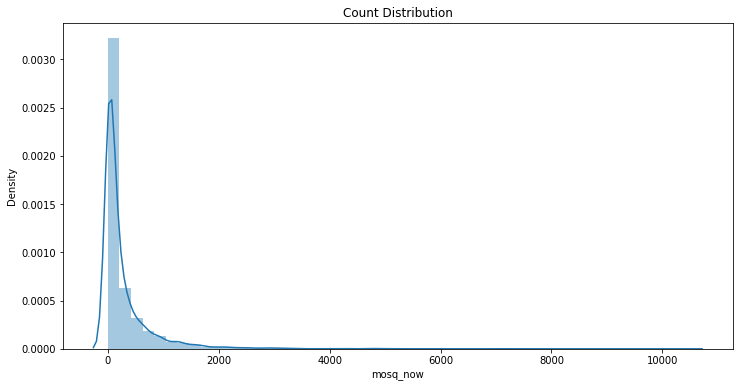

In [34]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [35]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

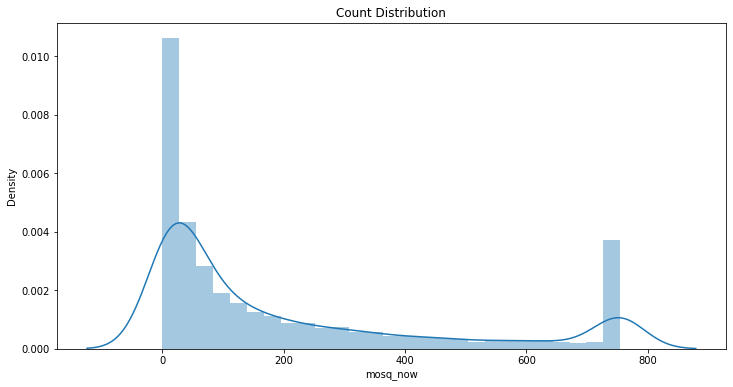

In [36]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

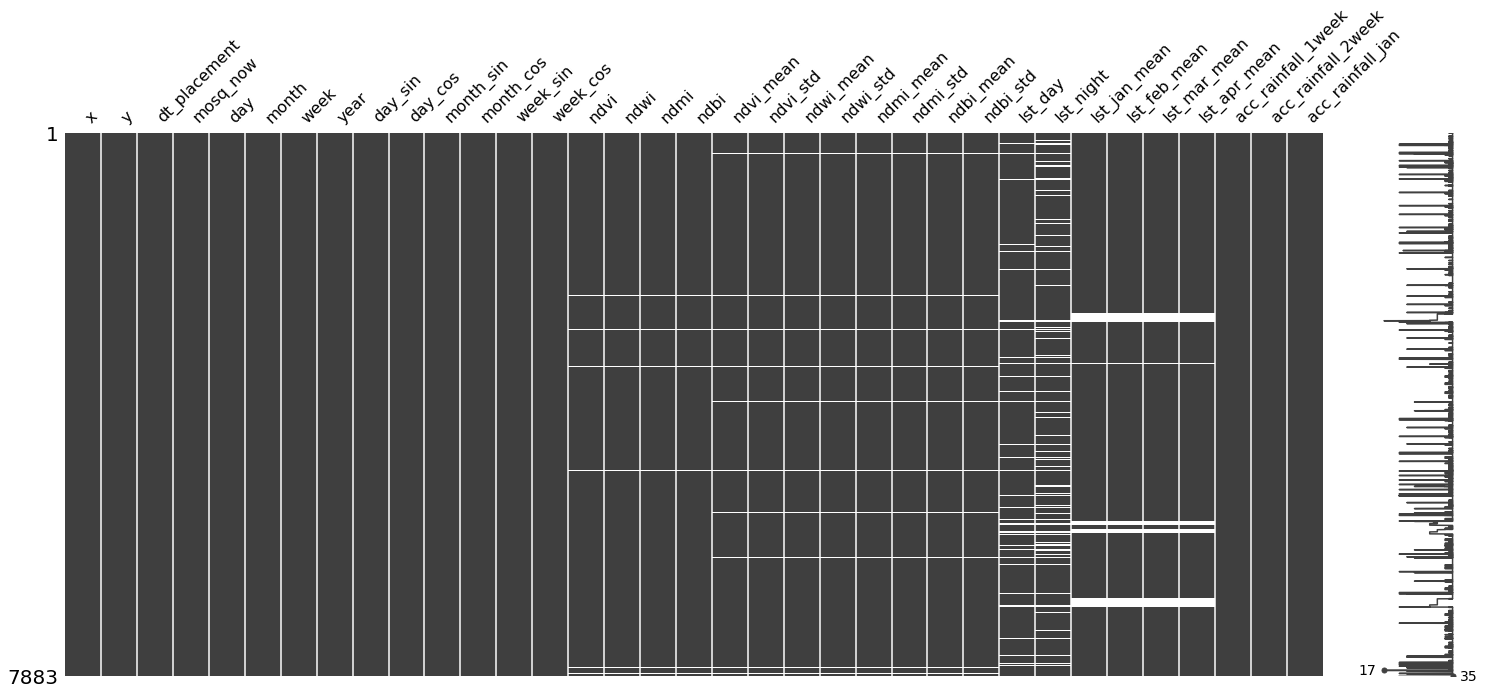

In [37]:
missingno.matrix(mosquito_data_nuts2)

In [38]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [39]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

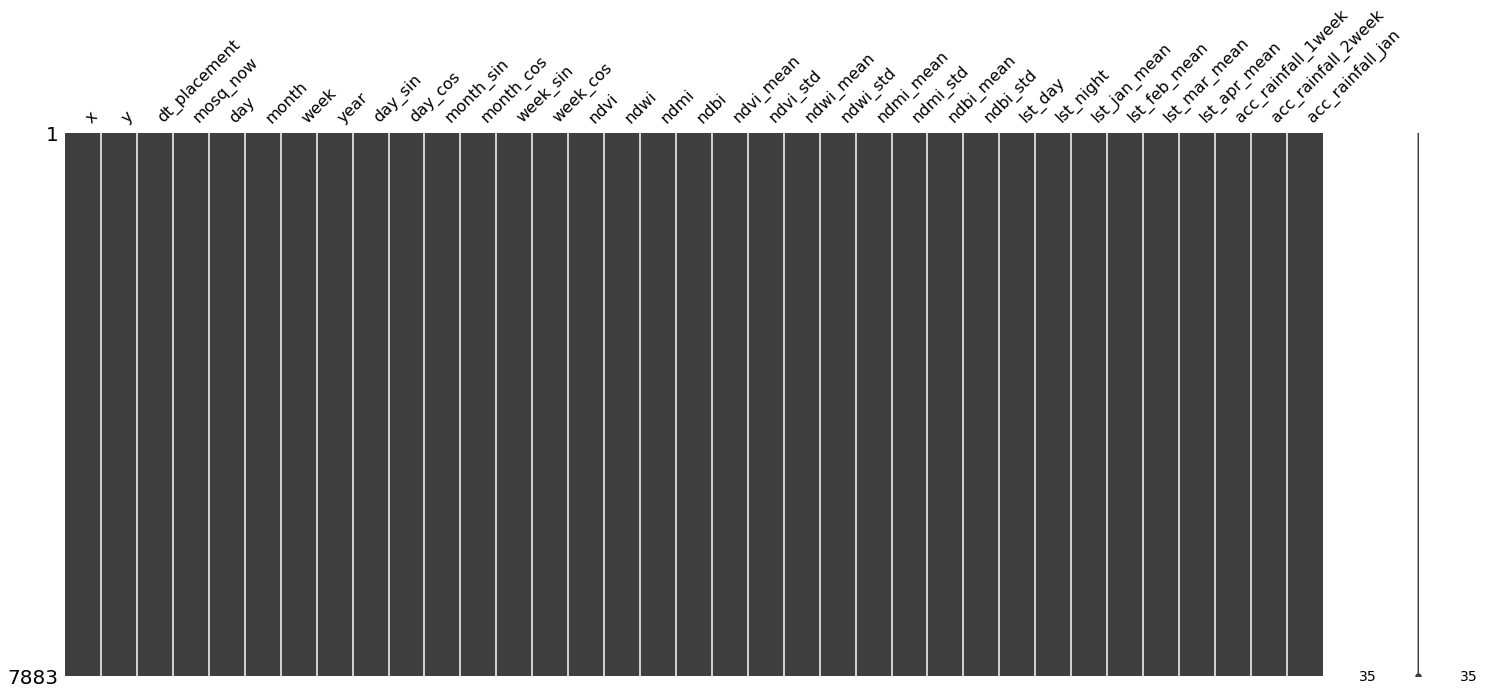

In [40]:
missingno.matrix(mosquito_data_nuts2)

In [41]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [42]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [43]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 20.88156 | Val Loss: 28.04762 | Train Acc: 2.829| Val Acc: 2.391
Epoch 002: | Train Loss: 18.25170 | Val Loss: 25.83768 | Train Acc: 2.175| Val Acc: 2.042
Epoch 003: | Train Loss: 18.39365 | Val Loss: 26.45861 | Train Acc: 2.220| Val Acc: 2.091
Epoch 004: | Train Loss: 18.41393 | Val Loss: 23.48310 | Train Acc: 2.199| Val Acc: 1.960
Epoch 005: | Train Loss: 17.55867 | Val Loss: 24.44497 | Train Acc: 2.031| Val Acc: 1.957
Epoch 006: | Train Loss: 17.67612 | Val Loss: 24.01365 | Train Acc: 2.090| Val Acc: 1.944
Epoch 007: | Train Loss: 17.55093 | Val Loss: 23.59853 | Train Acc: 2.081| Val Acc: 1.974
Epoch 008: | Train Loss: 17.16407 | Val Loss: 23.40674 | Train Acc: 2.029| Val Acc: 1.939
Epoch 009: | Train Loss: 16.96350 | Val Loss: 23.76958 | Train Acc: 2.008| Val Acc: 1.956
Epoch 010: | Train Loss: 16.78308 | Val Loss: 23.61138 | Train Acc: 1.984| Val Acc: 2.014
Epoch 011: | Train Loss: 16.54088 | Val Loss: 24.03076 | Train Acc: 1.962| Val Acc: 1.974
Epoch 012:

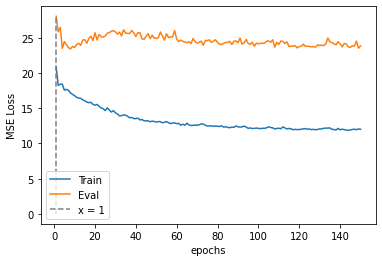

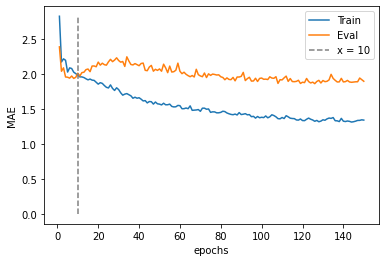

In [44]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [45]:
metrics(train, test, threshold=30)

MAE on train set:  167.8285712222639
min prediction: 1
max prediction: 741

MAE on test set:  150.01948991425547
Error ⩽ 30: 23.82 %
min prediction: 1
max prediction: 821


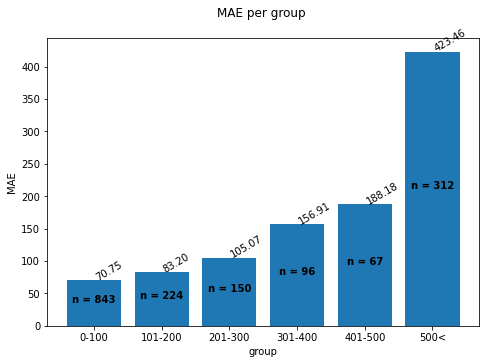

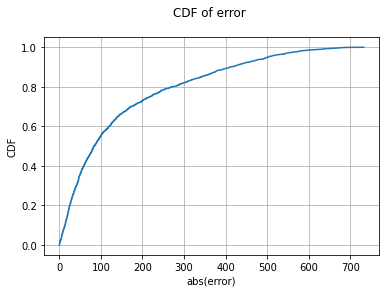

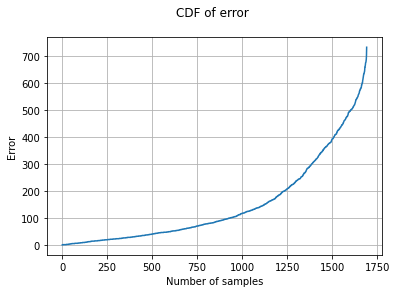

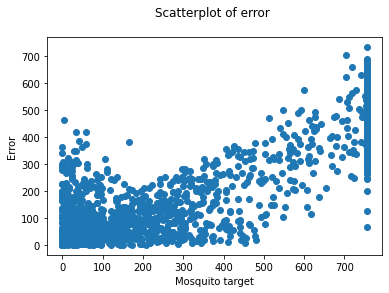

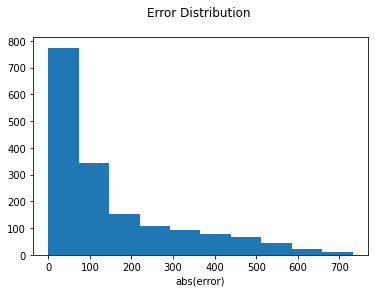

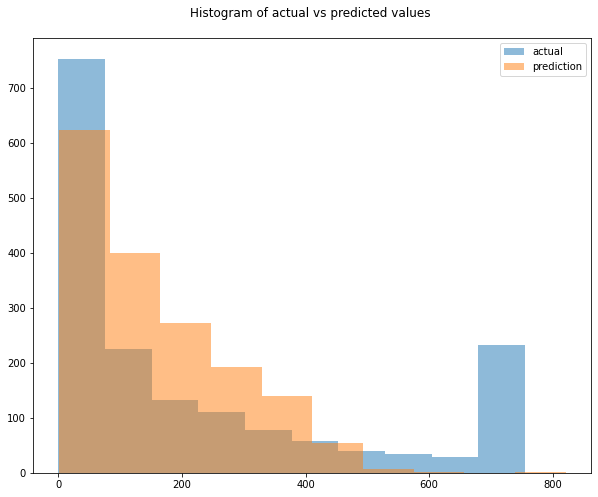

In [46]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.62791 | Val Loss: 1.88816 | Train Acc: 1.568| Val Acc: 1.633
Epoch 002: | Train Loss: 13.76026 | Val Loss: 2.12387 | Train Acc: 1.565| Val Acc: 1.633
Epoch 003: | Train Loss: 13.83024 | Val Loss: 1.47295 | Train Acc: 1.583| Val Acc: 1.633
Epoch 004: | Train Loss: 13.36752 | Val Loss: 1.10746 | Train Acc: 1.540| Val Acc: 0.633
Epoch 005: | Train Loss: 13.40741 | Val Loss: 1.62933 | Train Acc: 1.532| Val Acc: 1.633
Epoch 006: | Train Loss: 13.47126 | Val Loss: 1.57016 | Train Acc: 1.539| Val Acc: 1.633
Epoch 007: | Train Loss: 13.42203 | Val Loss: 2.00227 | Train Acc: 1.526| Val Acc: 1.633
Epoch 008: | Train Loss: 13.31188 | Val Loss: 3.57335 | Train Acc: 1.519| Val Acc: 1.633
Epoch 009: | Train Loss: 13.21544 | Val Loss: 2.48373 | Train Acc: 1.495| Val Acc: 1.633
Epoch 010: | Train Loss: 13.05130 | Val Loss: 2.63516 | Train Acc: 1.498| Val Acc: 1.633
Epoch 011: | Train Loss: 13.02176 | Val Loss: 2.57592 | Train Acc: 1.485| Val Acc: 1.633
Epoch 012: | Train Lo

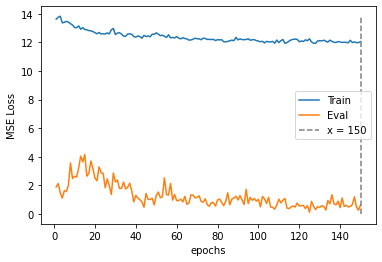

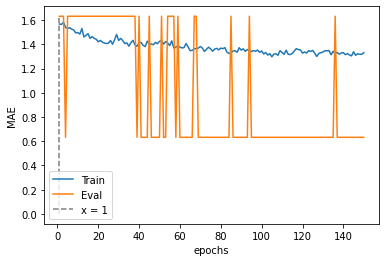

In [47]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [48]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [49]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [50]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [51]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [52]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [53]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

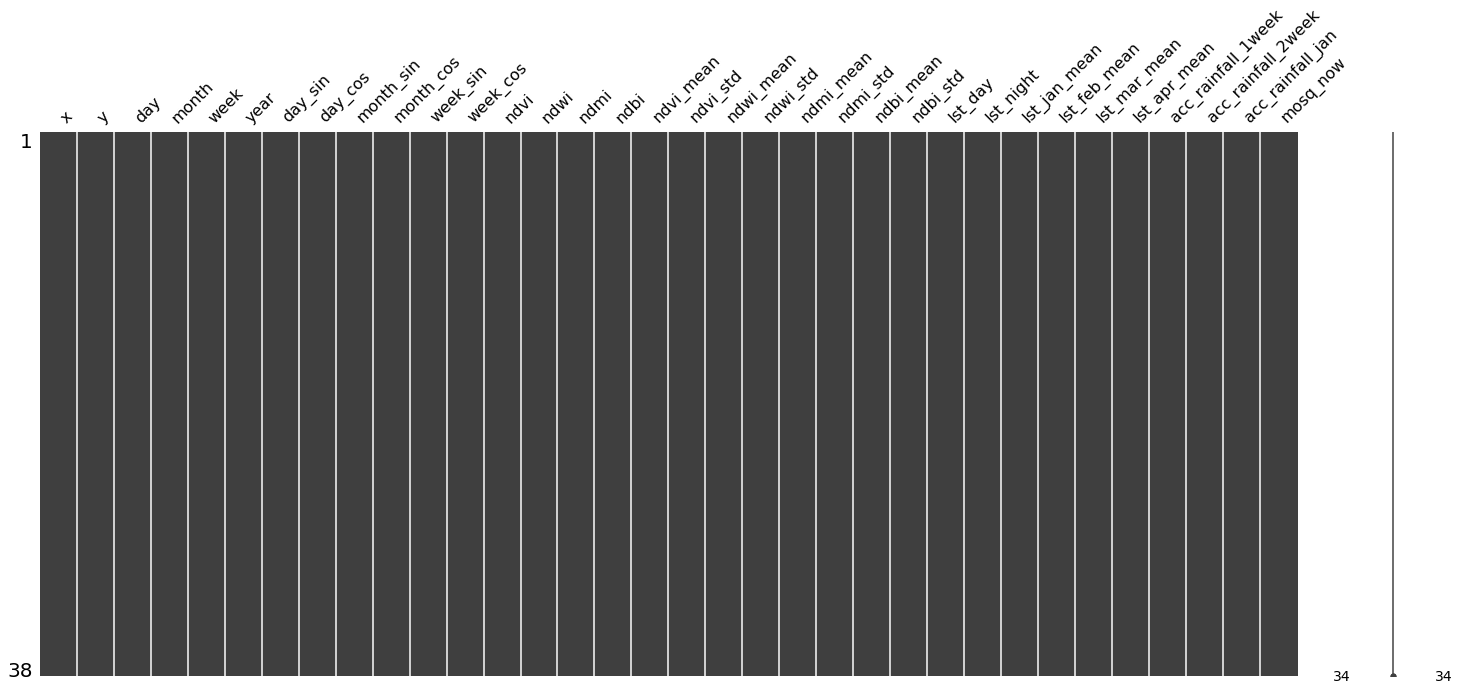

In [54]:
missingno.matrix(dataset_mamoth)

In [55]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [56]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [57]:
predictions = give_predictions(model, dataset_mamoth)

In [58]:
mosqutio_predictions['mosq_pred'] = predictions

In [59]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.483978,40.644680,2023-06-16,246
1,21.940791,40.977027,2023-06-16,48
2,22.891980,40.656030,2023-06-16,396
3,23.982527,40.915102,2023-06-16,61
4,23.691080,40.495934,2023-06-16,58
...,...,...,...,...
33,23.828106,40.110264,2023-06-16,68
34,23.388058,41.313484,2023-06-16,59
35,22.146700,40.822940,2023-06-16,62
36,22.723020,40.753567,2023-06-16,408


In [60]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-{MONTH}-{PERIOD}.csv', index = False)